In [2]:
# YouTube Trending Videos Cleaning Data
# Project Objective

# The objective of this project is to clean and preprocess the YouTube Trending Videos dataset by
# identifying and handling missing values, removing duplicate records, standardizing data formats,
# ensuring data integrity, and detecting outliers. The cleaned dataset will be suitable for exploratory data analysis (EDA),
# visualization, and machine learning applications.


In [58]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [59]:
from google.colab import files
upload = files.upload()

Saving USvideos.csv to USvideos (1).csv


In [60]:
df= pd.read_csv('USvideos.csv')
original_df= df.copy() # backup copy

In [61]:
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [63]:
df.describe()

,category_id,views,likes,dislikes,comment_count
count,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
std,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04
min,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


In [64]:
df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')

In [65]:
# 1) Data Integrity Checks -> Data integrity ensures the dataset is accurate, consistent, and reliable.
df.dtypes

,0
video_id,object
trending_date,object
title,object
channel_title,object
category_id,int64
publish_time,object
tags,object
views,int64
likes,int64
dislikes,int64


In [66]:
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


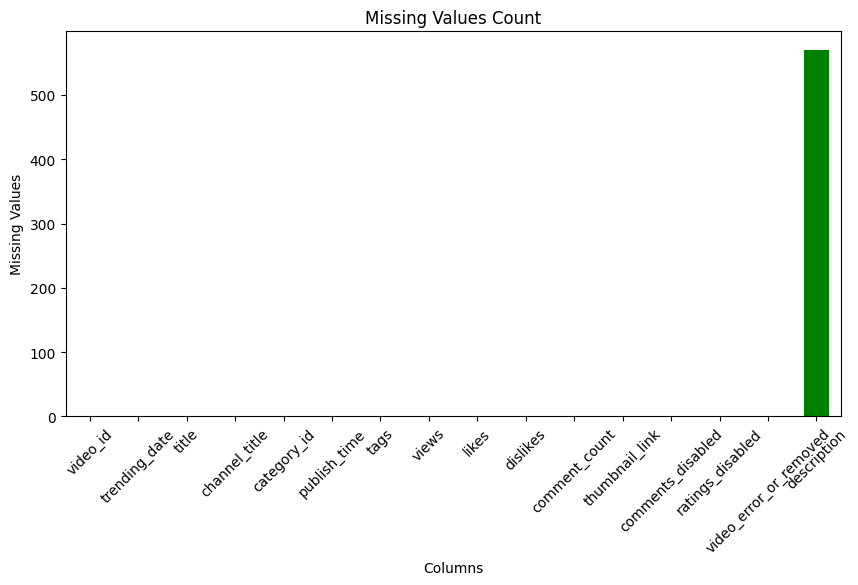

In [72]:
plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind='bar', color='green')
plt.title("Missing Values Count")
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.xticks(rotation=45)
plt.show()

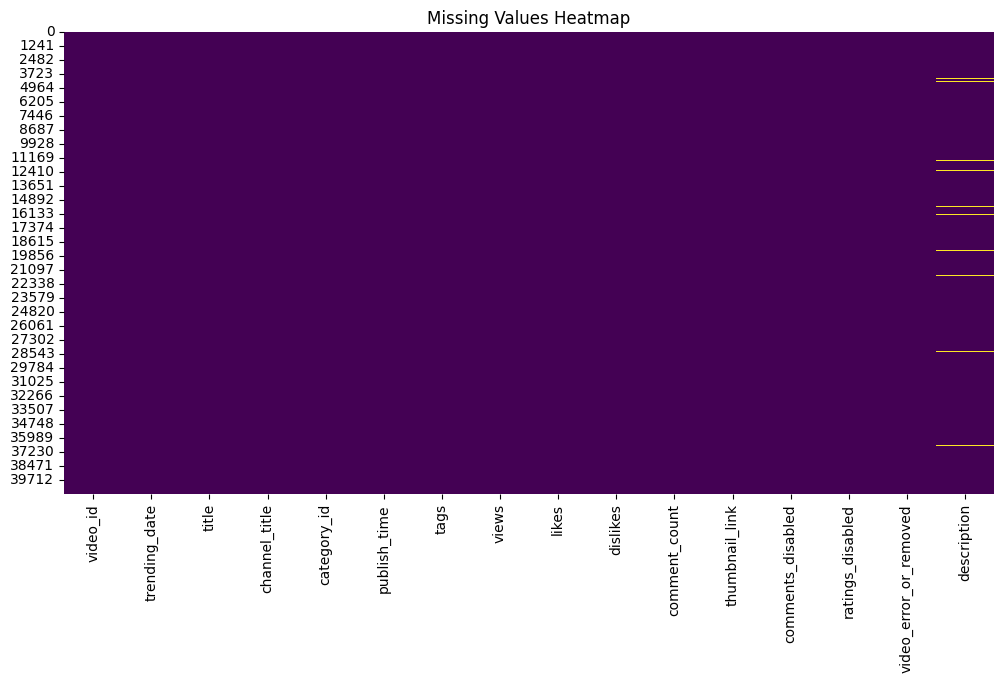

In [73]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [74]:
duplicates = df.duplicated().sum()
duplicates

np.int64(48)

In [75]:
df.drop_duplicates(inplace = True)

In [76]:
# Check Invalid Values
(df['views']< 0).sum()

np.int64(0)

In [77]:
(df['likes']<0).sum()

np.int64(0)

In [78]:
(df['dislikes']<0).sum()

np.int64(0)

In [79]:
(df['comment_count']<0).sum()

np.int64(0)

In [80]:
# check duplicate video ids
df['video_id'].duplicated().sum()

# Why?
# A video can trend on multiple days. ->So duplicate video IDs are expected, not errors.

np.int64(34550)

In [81]:
# Consistency Check
df['trending_date'].unique()

array(['17.14.11', '17.15.11', '17.16.11', '17.17.11', '17.18.11',
       '17.19.11', '17.20.11', '17.21.11', '17.22.11', '17.23.11',
       '17.24.11', '17.25.11', '17.26.11', '17.27.11', '17.28.11',
       '17.29.11', '17.30.11', '17.01.12', '17.02.12', '17.03.12',
       '17.04.12', '17.05.12', '17.06.12', '17.07.12', '17.08.12',
       '17.09.12', '17.10.12', '17.11.12', '17.12.12', '17.13.12',
       '17.14.12', '17.15.12', '17.16.12', '17.17.12', '17.18.12',
       '17.19.12', '17.20.12', '17.21.12', '17.22.12', '17.23.12',
       '17.24.12', '17.25.12', '17.26.12', '17.27.12', '17.28.12',
       '17.29.12', '17.30.12', '17.31.12', '18.01.01', '18.02.01',
       '18.03.01', '18.04.01', '18.05.01', '18.06.01', '18.07.01',
       '18.08.01', '18.09.01', '18.12.01', '18.13.01', '18.14.01',
       '18.15.01', '18.16.01', '18.17.01', '18.18.01', '18.19.01',
       '18.20.01', '18.21.01', '18.22.01', '18.23.01', '18.24.01',
       '18.25.01', '18.26.01', '18.27.01', '18.28.01', '18.29.

In [82]:
inconsistent = df[
    (df['ratings_disabled']== True) &
    (
        (df['likes'] > 0) |
        (df['dislikes'] > 0) |
        (df['comment_count'] > 0)
    )
]
print('Inconsistent Records: ', len(inconsistent))

Inconsistent Records:  62


In [83]:
inconsistent_comments = df[
    (df["comments_disabled"] == True) &
    (df["comment_count"] > 0)
]

print("Inconsistent Records:", len(inconsistent_comments))
# If comments are disabled, comment count should ideally be zero.

Inconsistent Records: 0


In [84]:
# 2)Missing Value Handling
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [85]:
df["description"] = df["description"].fillna("No Description")

In [86]:
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [87]:
# 3) Duplicate Removal
df.duplicated().sum()

np.int64(0)

In [88]:
df.drop_duplicates(inplace = True)

In [89]:
# 4) Data Standardization
# remove extra spaces
df['title'] = df['title'].str.strip()
df["channel_title"] = df["channel_title"].str.strip()
df["tags"] = df["tags"].str.strip()

In [90]:
# convert publish time
df['publish_time'] = pd.to_datetime(df['publish_time'])

In [91]:
# convert Trending Date
df['trending_date']= pd.to_datetime(
    df['trending_date'],
    format = "%y.%d.%m"
)

In [92]:
df.dtypes

,0
video_id,object
trending_date,datetime64[ns]
title,object
channel_title,object
category_id,int64
publish_time,"datetime64[ns, UTC]"
tags,object
views,int64
likes,int64
dislikes,int64


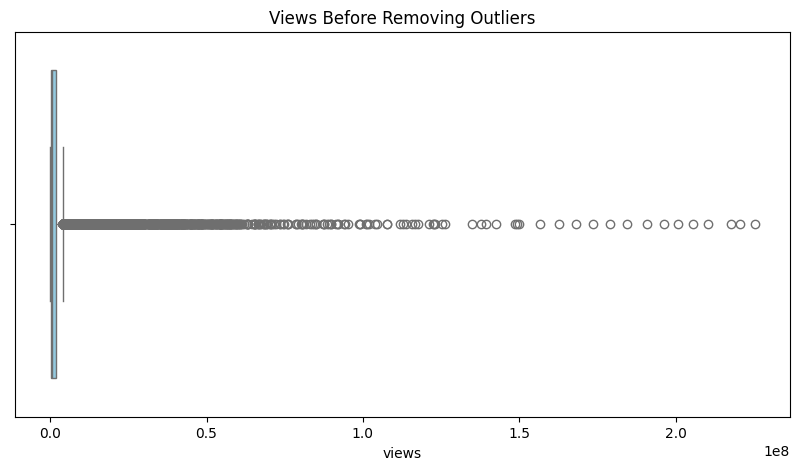

In [94]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['views'], color = 'skyblue')
plt.title("Views Before Removing Outliers")
plt.show()

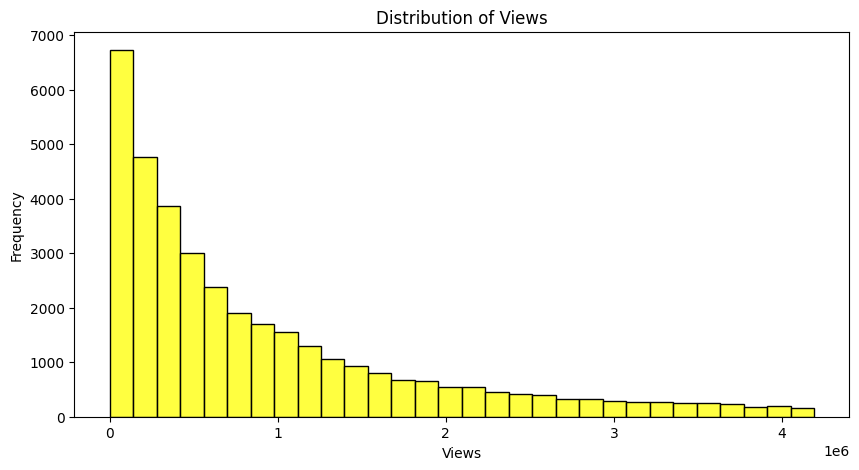

In [100]:
plt.figure(figsize=(10,5))
sns.histplot(clean_df['views'], bins=30, color ='yellow')
plt.title("Distribution of Views")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()

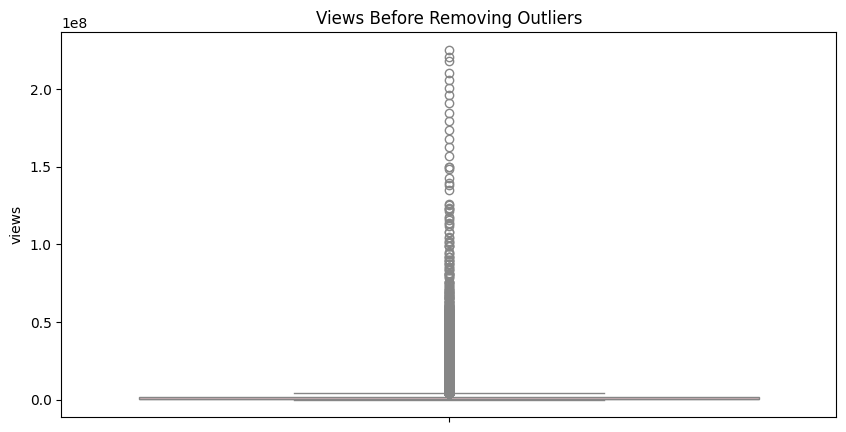

In [102]:
# Outlier Detection
plt.figure(figsize=(10,5))
sns.boxplot(df['views'], color="pink")
plt.title('Views Before Removing Outliers')
plt.show()

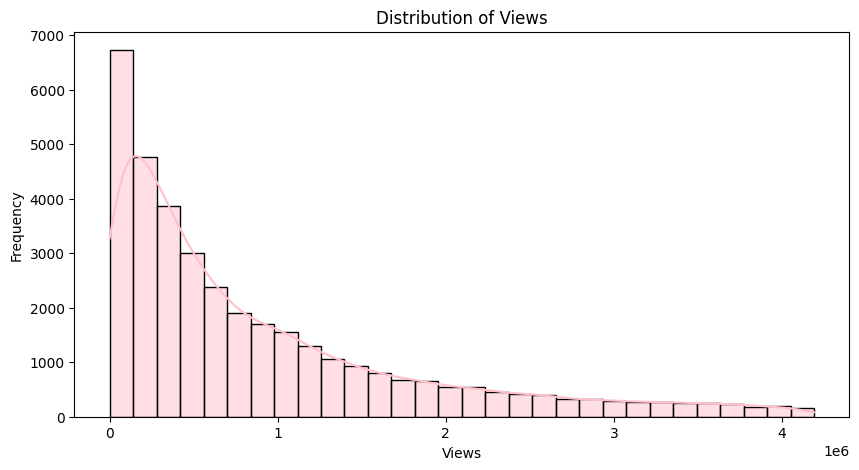

In [106]:
plt.figure(figsize=(10,5))
sns.histplot(clean_df['views'], bins=30, color = 'pink', kde= True)
plt.title("Distribution of Views")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()

In [107]:
# IQR
Q1 = df["views"].quantile(0.25)
Q3 = df["views"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Q1 = 241972.0
Q3 = 1821926.0
IQR = 1579954.0
Lower Bound: -2127959.0
Upper Bound: 4191857.0


In [108]:
# Detect Outliers
outliers = df[
    (df['views']< lower) | (df['views']> upper)
]
print("Outliers: ", len(outliers))

Outliers:  4497


In [109]:
# remove outliers

clean_df = df[
    (df['views']>= lower) & (df['views']<= upper)
]
print("Cleaned Dataset Shape:", clean_df.shape)

Cleaned Dataset Shape: (36404, 16)


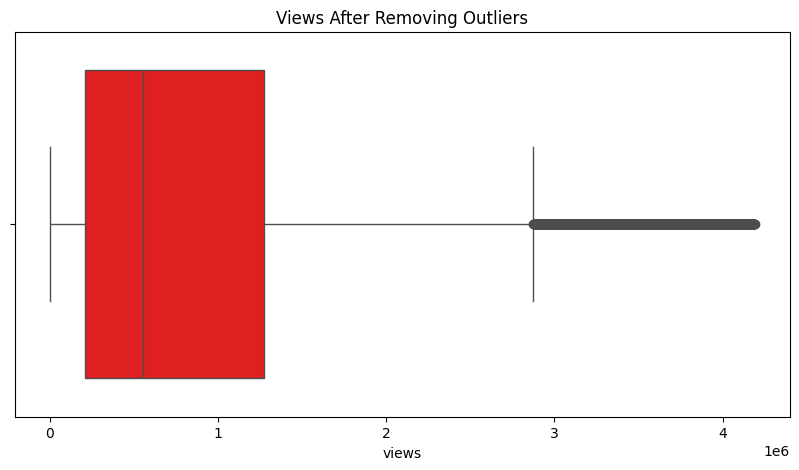

In [110]:
plt.figure(figsize=(10,5))
sns.boxplot(x=clean_df["views"], color ='red')
plt.title("Views After Removing Outliers")
plt.show()

In [111]:
# final Validation
print(clean_df.isnull().sum())

video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
dtype: int64


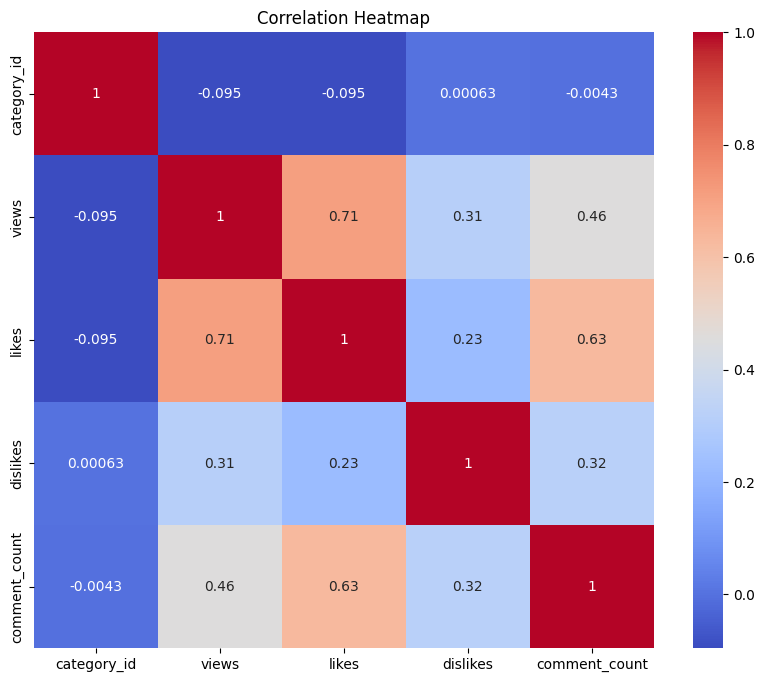

In [112]:
numeric_df = clean_df.select_dtypes(include='number')
plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

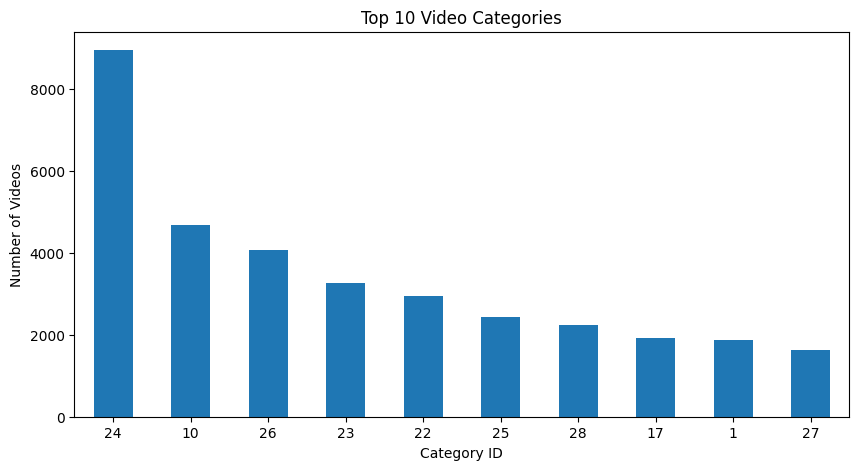

In [116]:
plt.figure(figsize=(10,5))
clean_df['category_id'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Video Categories")
plt.xlabel("Category ID")
plt.ylabel("Number of Videos")
plt.xticks(rotation=0)
plt.show()

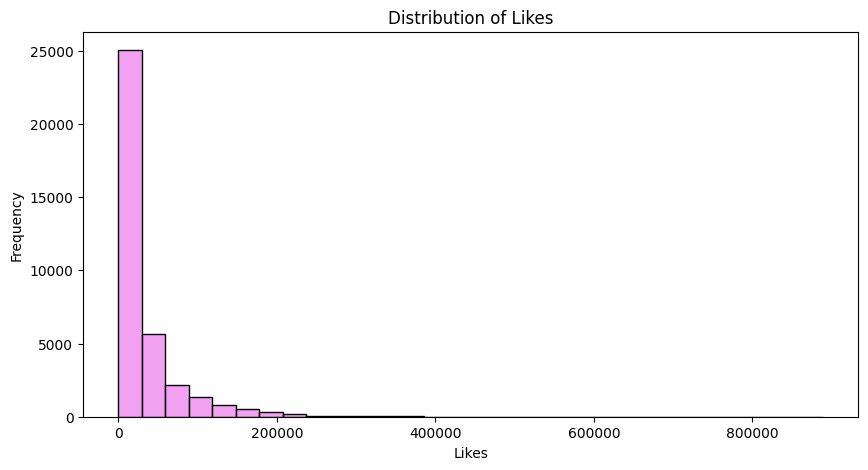

In [119]:
plt.figure(figsize=(10,5))
sns.histplot(clean_df['likes'], bins=30, color = 'violet')
plt.title("Distribution of Likes")
plt.xlabel("Likes")
plt.ylabel("Frequency")
plt.show()

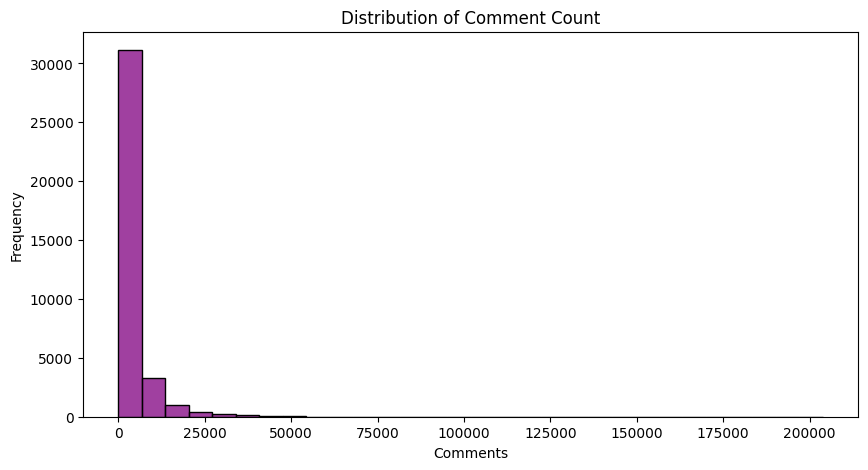

In [121]:
plt.figure(figsize=(10,5))
sns.histplot(clean_df['comment_count'], bins=30, color ='purple')
plt.title("Distribution of Comment Count")
plt.xlabel("Comments")
plt.ylabel("Frequency")
plt.show()

In [122]:
print(clean_df.duplicated().sum())

0


In [123]:
# Data Quality Score
quality_score = (
    (
        1 - clean_df.isnull().sum().sum() / (clean_df.shape[0] * clean_df.shape[1])
    )
) * 100
print(f"Data Quality Score: {quality_score:.2f}%")

Data Quality Score: 100.00%


In [124]:
# Before VS After
comparison = pd.DataFrame({
    "Before Cleaning": original_df.shape,
    "After Cleaning": clean_df.shape
},
index=["Rows","Columns"])
comparison

,Before Cleaning,After Cleaning
Rows,40949,36404
Columns,16,16


In [125]:
# Save Cleaned Dataset
clean_df.to_csv(
    "Cleaned_USvideos.csv",
    index = False
)
print("Dataset Saved Successfully")

Dataset Saved Successfully


In [126]:
from google.colab import files
files.download("Cleaned_USvideos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>